In [69]:
import pandas as pd
import numpy as np
import os
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [70]:
gold_data = pd.read_excel("../data/manual/pride_and_prejudice.xlsx", sheet_name="ALL INSTANCES")
gold_data["chapter"] = pd.to_numeric(gold_data["Graph Chapter"], errors="coerce").astype("Int64")
gold_data = gold_data.drop(columns=["Volume", "B", "FID", "Chapter", "Graph Chapter"])
gold_long = (
    gold_data.melt(
        id_vars=["chapter", "Character"],
        value_vars=["N","A","C","I","DN","DC"],
        var_name="tag",
        value_name="true_count"
    )
    .rename(columns={"Character":"character"})
)
gold_data.head()

,Character,N,DC,C,I,DN,A,Score,chapter
0,Captain Carter,2.0,2.0,0.0,0.0,0.0,0.0,4,7
1,Captain Carter,1.0,1.0,0.0,0.0,0.0,0.0,2,9
2,Charlotte Lucas,3.0,2.0,5.0,2.0,1.0,0.0,13,5
3,Charlotte Lucas,7.0,3.0,5.0,2.0,0.0,1.0,18,6
4,Charlotte Lucas,3.0,2.0,0.0,0.0,0.0,1.0,6,9


In [71]:
gold_data_je = pd.read_csv("../data/manual/JaneEyreTagging_January11.csv")
gold_data_je["chapter"] = pd.to_numeric(gold_data_je["CHAPTER"], errors="coerce").astype("Int64")
gold_data_je = gold_data_je.drop(columns=["B", "FID", "CHAPTER"]).rename(columns={"CHARACTER":"Character"})
gold_long_je = (
    gold_data_je.melt(
        id_vars=["chapter", "Character"],
        value_vars=["N","A","C","I","DN","DC"],
        var_name="tag",
        value_name="true_count"
    )
    .rename(columns={"Character":"character"})
)
gold_long_je.head()

,chapter,character,tag,true_count
0,1,Mrs. Reed,N,5.0
1,1,Jane,N,1.0
2,1,Bessie,N,4.0
3,1,Eliza Reed,N,6.0
4,1,John Reed,N,11.0


In [72]:
print("number of characters p&p", len(list(gold_data['Character'].value_counts().keys())))
print("number of characters je", len(list(gold_data_je['Character'].value_counts().keys())))

number of characters p&p 55
number of characters je 168


In [73]:
tags = ['N', 'A', 'C', 'I', 'DC', 'DN']
chapters = []
for t in tags:
    chapters.append(str(round(np.mean(list(gold_data.groupby('chapter')[t].sum())), 1)))
for t in tags:
    chapters.append(str(round(np.mean(list(gold_data_je.groupby('chapter')[t].sum())), 1)))
print(' & '.join(chapters))
characters = []
for t in tags:
    characters.append(str(round(np.mean(list(gold_data.groupby('Character')[t].sum())), 1)))
for t in tags:
    characters.append(str(round(np.mean(list(gold_data_je.groupby('Character')[t].sum())), 1)))
print(' & '.join(characters))
totals = []
for t in tags:
    totals.append(str(int(gold_data[t].sum())))
for t in tags:
    totals.append(str(int(gold_data_je[t].sum())))
print(' & '.join(totals))

52.3 & 29.9 & 23.1 & 32.9 & 60.3 & 7.7 & 67.1 & 143.5 & 79.9 & 110.2 & 88.7 & 22.1
58.0 & 33.1 & 25.6 & 36.5 & 66.9 & 8.5 & 15.2 & 32.5 & 18.1 & 24.9 & 20.1 & 5.0
3192 & 1823 & 1409 & 2006 & 3679 & 467 & 2548 & 5453 & 3038 & 4186 & 3371 & 839


In [74]:
def agg_results(df, gold):
    # Aggregate model outputs
    agg_model = (
        df.groupby(["method", "chapter", "character", "tag"])["count"]
        .sum()
        .reset_index()
    )

    # Merge model predictions with gold ground truth (align by chapter)
    merged = agg_model.merge(gold, on=["chapter", "character", "tag"], how="outer")
    merged["count"] = merged["count"].fillna(0)
    merged["true_count"] = merged["true_count"].fillna(0)
    merged["true_count"] = merged["true_count"].astype(int)

    mask_nonzero = (
        merged.groupby(["chapter", "character"])[["count", "true_count"]]
        .transform(lambda x: (x != 0).any())
    ).any(axis=1)

    merged_filtered = merged[mask_nonzero].copy().reset_index(drop=True)
    return merged_filtered

In [75]:
def run_metrics(df, gold):
    df = agg_results(df, gold)
    df = df.assign(
        error=lambda d: d["count"] - d["true_count"],
        abs_error=lambda d: (d["count"] - d["true_count"]).abs()
    )
    
    final_results = {}
    for tag in tags:
        temp_df = df[df['tag'] == tag]

        stats = (
            temp_df.groupby("chapter", as_index=False)
              .agg(
                  total_pred=("count", "sum"),
                  total_true=("true_count", "sum"),
                  mae=("abs_error", "mean"),
                  corr=("count", lambda x: np.corrcoef(x, temp_df.loc[x.index, "true_count"])[0, 1] 
                    if len(x) > 1 else np.nan)
              )
        )
        stats["bias"] = (stats["total_pred"] - stats["total_true"]) / stats["total_true"].replace(0, np.nan)
        final_results[tag] = (stats['mae'].mean().round(2), stats['bias'].mean().round(2), stats['corr'].mean().round(2))

    stats = (
        df.groupby("chapter", as_index=False)
          .agg(
              total_pred=("count", "sum"),
              total_true=("true_count", "sum"),
              mae=("abs_error", "mean"),
              corr=("count", lambda x: np.corrcoef(x, df.loc[x.index, "true_count"])[0, 1] 
                    if len(x) > 1 else np.nan)
          )
    )
    stats["bias"] = (stats["total_pred"] - stats["total_true"]) / stats["total_true"].replace(0, np.nan)
    final_results["average"] = (stats['mae'].mean().round(2), stats['bias'].mean().round(2), stats['corr'].mean().round(2))
    return final_results

In [95]:
def convert_name(txt, is_jane=False):
    chapter = "" if 'chapter' in txt else '\\tiny\\checkmark'
    chars = "" if 'all_gpt' in txt else '\\tiny\\checkmark'
    tags = "" if 'mini_all' in txt else '\\tiny\\checkmark'
    if is_jane:
        return [chapter, tags]
    return [chapter, chars, tags]

In [77]:
datadir = '../data/pride_and_jane/Pride_and_Prejudice/'
SETTINGS = {
    'chunk_size': ['chapter', '1000'],
    'characters': ['all', 'individual'],
    'LLM': ['gpt-4o-mini'],
    'components': ['all', 'individual']
}
COMBOS = [{
    'chunk_size': c,
    'characters': k,
    'LLM': l,
    'components': s
} for c in SETTINGS['chunk_size'] for k in SETTINGS['characters'] for l in SETTINGS['LLM'] for s in SETTINGS['components']]

for setting in COMBOS:
    filename = '_'.join(setting.values())
    if os.path.exists(f"{datadir}/{filename}_llm_counts.csv"):
        results_df = pd.read_csv(f"{datadir}/{filename}_llm_counts.csv")
        result = run_metrics(results_df, gold_long)
        result_row = convert_name(filename) + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
        result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
        print(' & '.join([str(x) for x in result_row]) + " \\\\")
print("\\midrule")  

results_df = pd.read_csv(f"{datadir}/pride_booknlp_tagged_components.csv")
result = run_metrics(results_df, gold_long)
result_row = ['BookNLP'] + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")
results_df = pd.read_csv(f"{datadir}/llm_spans.csv")
result = run_metrics(results_df, gold_long)
result_row = ['SpanLLM'] + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")
        

 &  &  & 2.28 & 1.98 & 1.48 & 2.11 & 4.14 & 1.08 & 2.18 & 0.75 & 0.66 & 0.67 & 0.74 & 0.47 & 0.49 & 0.57 \\
 &  & \tiny\checkmark & 2.08 & 2.33 & 1.79 & 2.0 & 4.06 & 1.59 & 2.31 & 0.78 & 0.66 & 0.66 & 0.77 & 0.49 & 0.46 & 0.58 \\
 & \tiny\checkmark &  & 3.36 & 1.64 & 1.82 & 2.24 & 3.72 & 2.66 & 2.57 & 0.78 & 0.71 & 0.69 & 0.72 & 0.54 & 0.5 & 0.57 \\
 & \tiny\checkmark & \tiny\checkmark & 4.0 & 4.75 & 3.36 & 12.48 & 3.92 & 2.67 & 5.2 & 0.78 & 0.65 & 0.66 & 0.8 & 0.53 & 0.46 & 0.53 \\
\tiny\checkmark &  &  & 3.56 & 1.82 & 1.31 & 1.98 & 3.81 & 1.85 & 2.39 & 0.84 & 0.7 & 0.71 & 0.73 & 0.58 & 0.5 & 0.58 \\
\tiny\checkmark &  & \tiny\checkmark & 2.95 & 4.25 & 2.47 & 3.18 & 3.6 & 2.92 & 3.23 & 0.86 & 0.73 & 0.67 & 0.77 & 0.6 & 0.48 & 0.64 \\
\tiny\checkmark & \tiny\checkmark &  & 9.09 & 1.6 & 2.38 & 4.16 & 3.54 & 5.14 & 4.32 & 0.8 & 0.73 & 0.67 & 0.71 & 0.58 & 0.48 & 0.57 \\
\tiny\checkmark & \tiny\checkmark & \tiny\checkmark & 4.58 & 12.69 & 4.62 & 26.12 & 5.08 & 4.57 & 9.61 & 0.83 & 0.67 & 

In [78]:
for setting in COMBOS:
    filename = '_'.join(setting.values())
    if os.path.exists(f"{datadir}/{filename}_llm_counts.csv"):
        results_df = pd.read_csv(f"{datadir}/{filename}_llm_counts.csv")
        result = run_metrics(results_df, gold_long)
        result_row = convert_name(filename) + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
        print(' & '.join([str(x) for x in result_row]) + " \\\\")
print("\\midrule")  

results_df = pd.read_csv(f"{datadir}/pride_booknlp_tagged_components.csv")
result = run_metrics(results_df, gold_long)
result_row = ['BookNLP'] + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")
results_df = pd.read_csv(f"{datadir}/llm_spans.csv")
result = run_metrics(results_df, gold_long)
result_row = ['SpanLLM'] + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")

 &  &  & -0.2 & -0.55 & 0.05 & -0.38 & -0.66 & 2.52 & -0.44 \\
 &  & \tiny\checkmark & -0.11 & 1.08 & 1.24 & 0.11 & -0.48 & 4.56 & -0.05 \\
 & \tiny\checkmark &  & 0.56 & 0.02 & 1.14 & 0.14 & -0.29 & 9.22 & 0.17 \\
 & \tiny\checkmark & \tiny\checkmark & 0.77 & 3.53 & 3.26 & 5.86 & 0.18 & 9.12 & 1.65 \\
\tiny\checkmark &  &  & 0.65 & -0.46 & 0.34 & 0.1 & -0.46 & 4.71 & 0.01 \\
\tiny\checkmark &  & \tiny\checkmark & 0.5 & 2.97 & 2.67 & 1.43 & 0.04 & 8.44 & 0.79 \\
\tiny\checkmark & \tiny\checkmark &  & 2.14 & 0.2 & 1.61 & 1.62 & 0.08 & 15.52 & 1.17 \\
\tiny\checkmark & \tiny\checkmark & \tiny\checkmark & 1.09 & 8.72 & 3.78 & 13.56 & 1.14 & 14.74 & 3.74 \\
\midrule
BookNLP & 0.06 & 0.76 & 0.17 & 0.3 & -0.02 & 0.43 & 0.03 \\
SpanLLM & -0.11 & -0.05 & 0.29 & -0.27 & -0.06 & 0.84 & -0.12 \\


In [98]:
datadir = '../data/pride_and_jane/Jane_Eyre/'
SETTINGS = {
    'chunk_size': ['chapter', '1000'],
    'characters': ['all'],
    'LLM': ['gpt-4o-mini'],
    'components': ['all', 'individual']
}
COMBOS = [{
    'chunk_size': c,
    'characters': k,
    'LLM': l,
    'components': s
} for c in SETTINGS['chunk_size'] for k in SETTINGS['characters'] for l in SETTINGS['LLM'] for s in SETTINGS['components']]

for setting in COMBOS:
    filename = '_'.join(setting.values())
    if os.path.exists(f"{datadir}/{filename}_llm_counts.csv"):
        results_df = pd.read_csv(f"{datadir}/{filename}_llm_counts.csv")
        result = run_metrics(results_df, gold_long_je)
        result_row = convert_name(filename, True) + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
        result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
        print(' & '.join([str(x) for x in result_row]) + " \\\\")
print("\\midrule")  

results_df = pd.read_csv(f"{datadir}jane_eyre_booknlp_tagged_components_old.csv")
result = run_metrics(results_df, gold_long_je)
result_row = ['\\multicolumn{2}{c}{BookNLP}'] + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\\\midrule")

results_df = pd.read_csv(f"{datadir}jane_eyre_booknlp_tagged_components.csv")
result = run_metrics(results_df, gold_long_je)
result_row = ['\\multicolumn{2}{c}{BookNLP \\faHandPaper}'] + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")
results_df = pd.read_csv(f"{datadir}/llm_spans.csv")
result = run_metrics(results_df, gold_long_je)
result_row = ['\\multicolumn{2}{c}{SpanLLM}'] + [result[x][0] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
result_row += [result[x][2] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")

 &  & 3.92 & 10.31 & 5.92 & 8.21 & 6.6 & 1.76 & 6.12 & 0.57 & 0.65 & 0.66 & 0.67 & 0.46 & 0.53 & 0.42 \\
 & \tiny\checkmark & 3.53 & 8.24 & 5.35 & 6.94 & 6.68 & 1.87 & 5.43 & 0.61 & 0.68 & 0.55 & 0.76 & 0.27 & 0.52 & 0.6 \\
\tiny\checkmark &  & 7.74 & 8.4 & 4.3 & 6.8 & 5.89 & 2.7 & 5.97 & 0.68 & 0.66 & 0.66 & 0.67 & 0.48 & 0.61 & 0.45 \\
\tiny\checkmark & \tiny\checkmark & 5.05 & 7.75 & 4.1 & 7.11 & 5.92 & 4.04 & 5.66 & 0.78 & 0.74 & 0.7 & 0.8 & 0.46 & 0.58 & 0.71 \\
\midrule
\multicolumn{2}{c|}{BookNLP} & 1.57 & 7.4 & 4.55 & 7.12 & 4.25 & 1.23 & 4.35 & 0.86 & 0.52 & 0.49 & 0.29 & 0.62 & 0.42 & 0.46 \\\midrule
\multicolumn{2}{c|}{BookNLP \faHandPaper} & 1.57 & 4.89 & 3.17 & 4.16 & 3.48 & 1.18 & 3.08 & 0.86 & 0.89 & 0.82 & 0.91 & 0.8 & 0.56 & 0.86 \\
\multicolumn{2}{c|}{SpanLLM} & 3.06 & 8.5 & 3.07 & 7.71 & 4.08 & 1.3 & 4.62 & 0.62 & 0.79 & 0.81 & 0.76 & 0.77 & 0.52 & 0.55 \\


In [97]:
for setting in COMBOS:
    filename = '_'.join(setting.values())
    if os.path.exists(f"{datadir}/{filename}_llm_counts.csv"):
        results_df = pd.read_csv(f"{datadir}/{filename}_llm_counts.csv")
        result = run_metrics(results_df, gold_long_je)
        result_row = convert_name(filename, True) + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
        print(' & '.join([str(x) for x in result_row]) + " \\\\")
print("\\midrule")  

results_df = pd.read_csv(f"{datadir}/jane_eyre_booknlp_tagged_components_old.csv")
result = run_metrics(results_df, gold_long_je)
result_row = ['\\multicolumn{2}{c|}{BookNLP}'] + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\\\midrule")

results_df = pd.read_csv(f"{datadir}/jane_eyre_booknlp_tagged_components.csv")
result = run_metrics(results_df, gold_long_je)
result_row = ['\\multicolumn{2}{c|}{BookNLP \\faHandPaper}'] + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")
results_df = pd.read_csv(f"{datadir}/llm_spans.csv")
result = run_metrics(results_df, gold_long_je)
result_row = ['\\multicolumn{2}{c|}{SpanLLM}'] + [result[x][1] for x in ['N', 'A', 'C', 'I', 'DC', 'DN', 'average']]
print(' & '.join([str(x) for x in result_row]) + " \\\\")

 &  & -0.3 & -0.9 & -0.76 & -0.77 & -0.74 & 0.62 & -0.73 \\
 & \tiny\checkmark & -0.32 & -0.62 & -0.47 & -0.44 & -0.68 & 0.84 & -0.54 \\
\tiny\checkmark &  & 0.95 & -0.73 & -0.44 & -0.42 & -0.57 & 1.87 & -0.34 \\
\tiny\checkmark & \tiny\checkmark & 0.55 & 0.18 & 0.19 & 0.6 & -0.06 & 3.66 & 0.26 \\
\midrule
\multicolumn{2}{c|}{BookNLP} & -0.01 & -0.64 & -0.53 & -0.74 & -0.2 & -0.75 & -0.51 \\\midrule
\multicolumn{2}{c|}{BookNLP \faHandPaper} & -0.01 & -0.22 & -0.24 & -0.18 & 0.0 & -0.26 & -0.2 \\
\multicolumn{2}{c|}{SpanLLM} & -0.37 & -0.76 & 0.14 & -0.8 & 0.13 & -0.45 & -0.44 \\


In [106]:
def plot_pp(axes, num, results_df, method_order, palette):
    # Load gold annotated data
    merged_filtered = {}
    model_totals = {}
    for key, df in results_df.items():
        # Aggregate model outputs
        agg_model = (
            df.groupby(["method", "chapter", "character", "tag"])["count"]
            .sum()
            .reset_index()
        )

        # Merge model predictions with gold ground truth (align by chapter)
        merged = agg_model.merge(gold_long, on=["chapter", "character", "tag"], how="outer")
        merged["count"] = merged["count"].fillna(0)
        merged["true_count"] = merged["true_count"].fillna(0)
        merged["true_count"] = merged["true_count"].astype(int)

        mask_nonzero = (
            merged.groupby(["chapter", "character"])[["count", "true_count"]]
            .transform(lambda x: (x != 0).any())
        ).any(axis=1)

        merged_filtered[key] = merged[mask_nonzero].copy().reset_index(drop=True)
        model_totals[key] = merged_filtered[key].groupby(["character", "method"], as_index=False)["count"].sum()

    # Deduplicate gold (remove triple count)
    gold_totals = (
        merged_filtered['booknlp']
        .groupby(["chapter", "character", "tag"], as_index=False)["true_count"]
        .max()
        .groupby(["character"], as_index=False)["true_count"]
        .sum()
    )
    gold_totals["method"] = "gold"
    gold_totals = gold_totals.rename(columns={"true_count": "count"})

    # Combine into one DataFrame
    temp = [gold_totals] + list(model_totals.values())
    plot_df = pd.concat(temp, ignore_index=True)

    # determine top 20 characters by gold total 
    top_chars = (
        gold_totals.sort_values("count", ascending=False)
        .head(num)["character"].tolist()
    )

    plot_df["character"] = pd.Categorical(
        plot_df["character"], categories=top_chars, ordered=True
    )

    sns.barplot(
        data=plot_df,
        y="character", x="count", hue="method",
        order=top_chars,
        hue_order=method_order,
        palette=palette,
        edgecolor="black",
        linewidth=0.4,
        dodge=True,
        errorbar=None,
        ax=axes
    )

    axes.set_title(f"Top {num} characters")
    axes.set_xlabel("Component score")
    axes.set_ylabel("")
    axes.legend(frameon=False, loc="lower right", title="")
    return model_totals, gold_totals, merged_filtered

In [117]:
def plot_pp2(axes, num, model_totals, gold_totals, method_order, palette):
    # Combine into one DataFrame
    temp = [gold_totals] + list(model_totals.values())
    plot_df = pd.concat(temp, ignore_index=True)

    # determine top 20 characters by gold total 
    top_chars = (
        gold_totals.sort_values("count", ascending=True)
        .head(num)["character"].tolist()
    )

    plot_df["character"] = pd.Categorical(
        plot_df["character"], categories=top_chars, ordered=True
    )

    sns.barplot(
        data=plot_df,
        y="character", x="count", hue="method",
        order=top_chars,#char_order,
        hue_order=method_order,
        palette=palette,
        edgecolor="black",
        linewidth=0.4,
        dodge=True,
        errorbar=None,
        ax=axes
    )

    axes.set_title("$\it{Pride\ and\ Prejudice}$"+f": Bottom {num} characters")
    axes.set_xlabel("Component score")
    axes.set_ylabel("")
    axes.get_legend().remove()

In [121]:
def plot_ppcharacter_breakdown(char_name, axes, results_df, merged_filtered, method_order, palette):
    """Plot true vs. predicted tag counts for one character, with gold's bar first."""

    # --- model predictions (summed across all chapters)
    pred = {}
    for key, df in results_df.items():
        pred[key] = (
            merged_filtered[key][merged_filtered[key]["character"].str.contains(char_name, case=False)]
            .groupby(["tag", "method"], as_index=False)["count"].sum()
        )

    # --- gold truth (directly from original data)
    true = (
        gold_long[gold_long["character"].str.contains(char_name, case=False)]
        .groupby("tag", as_index=False)["true_count"].sum()
    )

    # --- consistent tag order
    tag_order = ["N", "A", "C", "I", "DN", "DC"]
    for df in list(pred.values()) + [true]:
        df["tag"] = pd.Categorical(df["tag"], categories=tag_order, ordered=True)

    # --- merge true + predicted (gold first)
    true["method"] = "gold"
    true = true.rename(columns={"true_count": "count"})
    plot_df = pd.concat(list(pred.values()) + [true], ignore_index=True)

    # --- plot
    sns.barplot(
        data=plot_df,
        x="tag", y="count", hue="method",
        hue_order=method_order,
        palette=palette, errorbar=None,
        ax=axes
    )
    axes.set_title("$\it{(Pride\ and\ Prejudice)}$"+f" {char_name}")
    axes.set_ylabel("")
    axes.get_legend().remove()
    axes.set_xlabel("")

In [109]:
def plot_je(axes, num, results_df, method_order, palette):
    merged_filtered = {}
    model_totals = {}
    for key, df in results_df.items():
        # Aggregate model outputs
        agg_model = (
            df.groupby(["method", "chapter", "character", "tag"])["count"]
            .sum()
            .reset_index()
        )

        # Merge model predictions with gold ground truth (align by chapter)
        merged = agg_model.merge(gold_long_je, on=["chapter", "character", "tag"], how="outer")
        merged["count"] = merged["count"].fillna(0)
        merged["true_count"] = merged["true_count"].fillna(0)
        merged["true_count"] = merged["true_count"].astype(int)

        mask_nonzero = (
            merged.groupby(["chapter", "character"])[["count", "true_count"]]
            .transform(lambda x: (x != 0).any())
        ).any(axis=1)

        merged_filtered[key] = merged[mask_nonzero].copy().reset_index(drop=True)
        model_totals[key] = merged_filtered[key].groupby(["character", "method"], as_index=False)["count"].sum()

    # Deduplicate gold (remove triple count)
    gold_totals = (
        merged_filtered['booknlp']
        .groupby(["chapter", "character", "tag"], as_index=False)["true_count"]
        .max()
        .groupby(["character"], as_index=False)["true_count"]
        .sum()
    )
    gold_totals["method"] = "gold"
    gold_totals = gold_totals.rename(columns={"true_count": "count"})

    # Combine into one DataFrame
    temp = [gold_totals] + list(model_totals.values())
    plot_df = pd.concat(temp, ignore_index=True)

    # determine top 20 characters by gold total 
    top_chars = (
        gold_totals.sort_values("count", ascending=False)
        .head(num)["character"].tolist()
    )

    plot_df["character"] = pd.Categorical(
        plot_df["character"], categories=top_chars, ordered=True
    )

    sns.barplot(
        data=plot_df,
        y="character", x="count", hue="method",
        order=top_chars,
        hue_order=method_order,
        palette=palette,
        edgecolor="black",
        linewidth=0.4,
        dodge=True,
        errorbar=None,
        ax=axes
    )

    axes.set_title(f"Top {num} characters")
    axes.set_xlabel("Component score")
    axes.set_ylabel("")
    return model_totals, gold_totals, merged_filtered

In [131]:
def plot_je2(axes, num, model_totals, gold_totals, method_order, palette):
    # Combine into one DataFrame
    temp = [gold_totals] + list(model_totals.values())
    plot_df = pd.concat(temp, ignore_index=True)

    # determine top 20 characters by gold total 
    top_chars = (
        gold_totals.sort_values("count", ascending=True)
        .head(num)["character"].tolist()
    )

    plot_df["character"] = pd.Categorical(
        plot_df["character"], categories=top_chars, ordered=True
    )

    sns.barplot(
        data=plot_df,
        y="character", x="count", hue="method",
        order=top_chars,
        hue_order=method_order,
        palette=palette,
        edgecolor="black",
        linewidth=0.4,
        dodge=True,
        errorbar=None,
        ax=axes
    )
    axes.set_title("$\it{Jane\ Eyre}$"+f": Bottom {num} characters")
    axes.set_xlabel("Component score")
    axes.set_ylabel("")
    axes.legend()

In [124]:
def plot_jecharacter_breakdown(char_name, axes, results_df, merged_filtered, method_order, palette):
    """Plot true vs. predicted tag counts for one character, with gold's bar first."""

    # --- model predictions (summed across all chapters)
    pred = {}
    for key, df in results_df.items():
        pred[key] = (
            merged_filtered[key][merged_filtered[key]["character"].str.contains(char_name, case=False)]
            .groupby(["tag", "method"], as_index=False)["count"].sum()
        )

    # --- gold truth (directly from original data)
    true = (
        gold_long_je[gold_long_je["character"].str.contains(char_name, case=False)]
        .groupby("tag", as_index=False)["true_count"].sum()
    )

    # --- consistent tag order
    tag_order = ["N", "A", "C", "I", "DN", "DC"]
    for df in list(pred.values()) + [true]:
        df["tag"] = pd.Categorical(df["tag"], categories=tag_order, ordered=True)

    # --- merge true + predicted (gold first)
    true["method"] = "gold"
    true = true.rename(columns={"true_count": "count"})
    plot_df = pd.concat(list(pred.values()) + [true], ignore_index=True)

    # --- plot
    sns.barplot(
        data=plot_df,
        x="tag", y="count", hue="method",
        hue_order=method_order,
        palette=palette, errorbar=None,
        ax=axes
    )
    axes.set_title("($\it{Jane\ eyre}$)"+f" {char_name}")
    axes.set_ylabel("")
    axes.set_xlabel("")
    axes.get_legend().remove()

In [112]:
plt.rcParams.update({
    'font.size': 16,          # Base font size
    'axes.titlesize': 16,     # Subplot titles
    'axes.labelsize': 16,     # X and Y labels
    'xtick.labelsize': 14,    # X tick labels
    'ytick.labelsize': 14,    # Y tick labels
    'legend.fontsize': 12
})

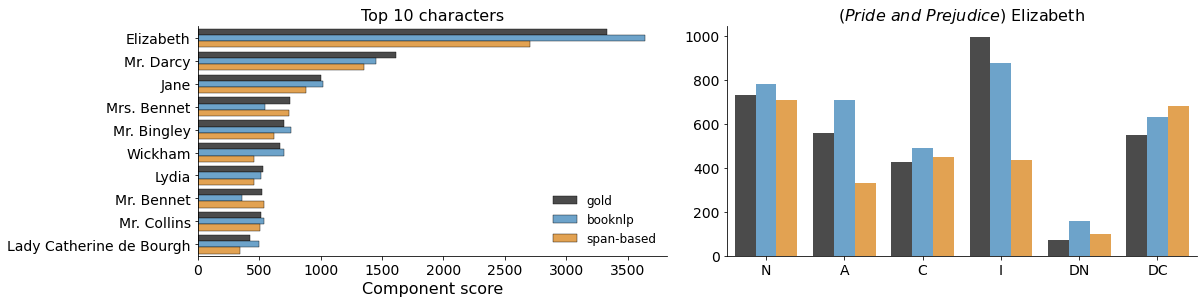

In [127]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 4.5),
    gridspec_kw={'width_ratios': [2, 2]}
)
axes = axes.flat
num=10

results_df = {
    'booknlp': pd.read_csv(f"../data/pride_and_jane/Pride_and_Prejudice/pride_booknlp_tagged_components.csv"),
    'span-based': pd.read_csv("../data/pride_and_jane/Pride_and_Prejudice/llm_spans.csv"),
}
method_order = ["gold", "booknlp", "span-based"]
palette = {
    "gold": "#4B4B4B",
    "booknlp": "#5DA5DA", 
    "span-based": "#FAA43A", 
}
model_totals, gold_totals, merged_filtered = plot_pp(axes[0],num, results_df, method_order, palette)
plot_ppcharacter_breakdown('Elizabeth', axes[1], results_df, merged_filtered, method_order, palette)

sns.despine()
plt.tight_layout()
plt.show()

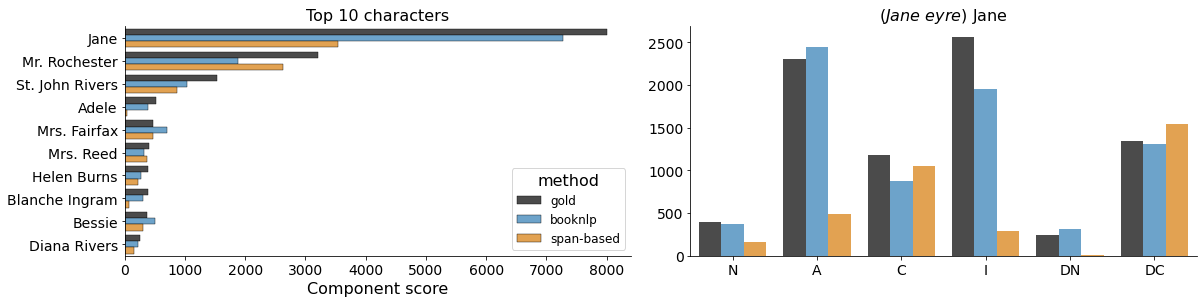

In [128]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 4.5),
    gridspec_kw={'width_ratios': [2, 2]}
)
axes = axes.flat
num=10

results_df_je = {
    'booknlp': pd.read_csv(f"../data/pride_and_jane/Jane_Eyre/jane_eyre_booknlp_tagged_components.csv"),
    'span-based': pd.read_csv("../data/pride_and_jane/Jane_Eyre/llm_spans.csv"),
}
method_order_je = ["gold", "booknlp", "span-based"]
palette_je = {
    "gold": "#4B4B4B",
    "booknlp": "#5DA5DA", 
    "span-based": "#FAA43A", 
}
model_totals_je, gold_totals_je, merged_filtered_je = plot_je(axes[0],num, results_df_je, method_order_je, palette_je)
plot_jecharacter_breakdown('Jane', axes[1], results_df_je, merged_filtered_je, method_order_je, palette_je)

sns.despine()
plt.tight_layout()
plt.show()

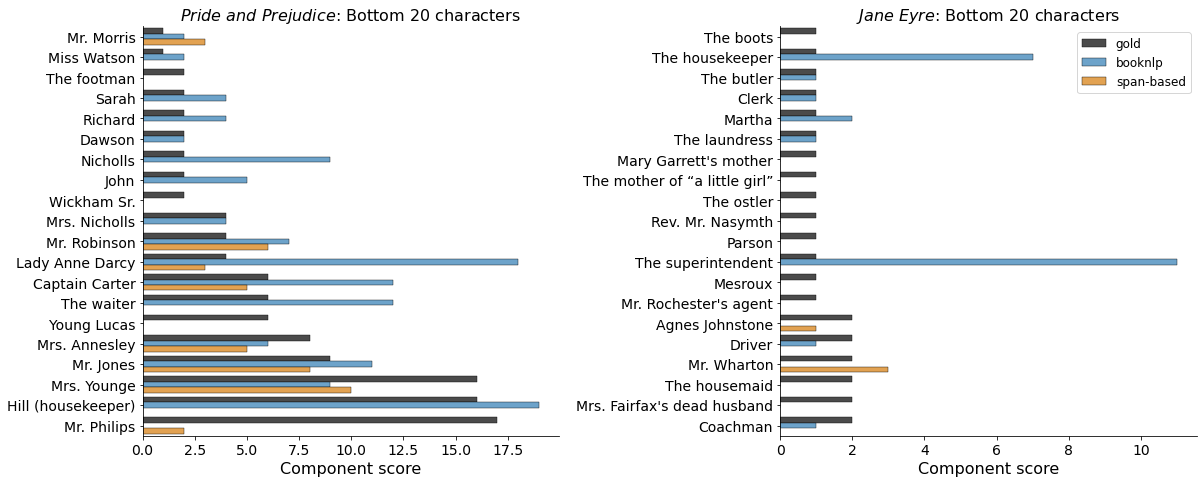

In [133]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 7),
    gridspec_kw={'width_ratios': [2, 2]}
)
axes = axes.flat
num=20
plot_pp2(axes[0],num, model_totals, gold_totals, method_order, palette)
plot_je2(axes[1],num, model_totals_je, gold_totals_je, method_order_je, palette_je)
sns.despine()
plt.tight_layout()
plt.show()

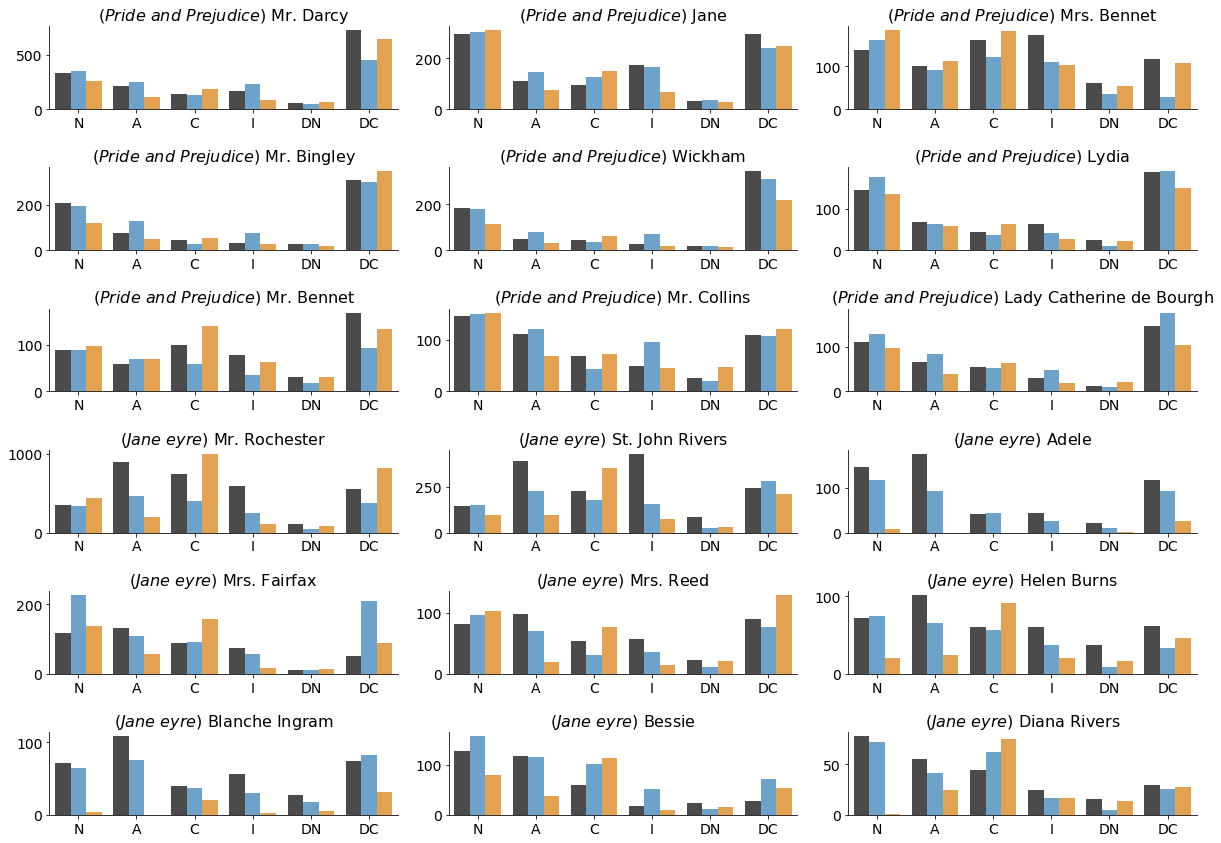

In [130]:
fig, axes = plt.subplots(
    6, 3,
    figsize=(17, 12),
    gridspec_kw={'width_ratios': [1, 1, 1]}
)
axes = axes.flat
pp_characters = ['Mr. Darcy', 'Jane', 'Mrs. Bennet', 'Mr. Bingley', 'Wickham', 'Lydia', 'Mr. Bennet', 'Mr. Collins', 'Lady Catherine de Bourgh']
je_characters = ['Mr. Rochester', 'St. John Rivers', 'Adele', 'Mrs. Fairfax', 'Mrs. Reed', 'Helen Burns', 'Blanche Ingram', 'Bessie', 'Diana Rivers']

for i, pp in enumerate(pp_characters):
    plot_ppcharacter_breakdown(pp, axes[i], results_df, merged_filtered, method_order, palette)
    
for i, je in enumerate(je_characters):
    plot_jecharacter_breakdown(je, axes[9+i], results_df_je, merged_filtered_je, method_order_je, palette_je)

sns.despine()
plt.tight_layout()
plt.show()